## Phase Retrieval with Error Reduction (ER) and Hybrid Input-Output (HIO)

In the previous notebook, **digital holography** recovered the complex field by adding a known reference wave. Here we remove the reference wave.

Now the only measurement is:

$$
I(k_x,k_y)=|\mathcal{F}\{U(x,y)\}|^2.
$$

The detector gives us the **Fourier magnitude**, but not the Fourier phase.

The phase-retrieval question is:

> Can we recover $U(x,y)$ when we only know the intensity of its far-field diffraction pattern?

This is the basic problem behind coherent diffractive imaging (CDI), and similarly in ptychography.



### Big picture

A coherent object field can be written as:

$$
U(x,y)=A(x,y)e^{i\phi(x,y)}.
$$

In far-field coherent diffraction, the detector measures:

$$
I(k_x,k_y)=|\hat{U}(k_x,k_y)|^2,
$$

where

$$
\hat{U}(k_x,k_y)=\mathcal{F}\{U(x,y)\}.
$$

So we know:

$$
|\hat{U}(k_x,k_y)|=\sqrt{I(k_x,k_y)}
$$

but we do **not** know:

$$
\arg \hat{U}(k_x,k_y).
$$

That missing Fourier phase is the problem.

To recover it, we add prior information in real space. In this notebook, the prior is a **support constraint**:

$$
U(x,y)=0 \quad \text{outside a known support region}.
$$

So the object must satisfy two constraints:

1. **Fourier modulus constraint**

   $$
   |\hat{U}(k_x,k_y)|=\sqrt{I(k_x,k_y)}.
   $$

2. **Real-space support constraint**

   $$
   U(x,y)=0 \quad \text{outside support}.
   $$

ER and HIO are iterative algorithms that bounce between these two constraints.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Fourier functions

In [2]:
def F2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(u)))

def iF2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(u)))

### Define object and support

We use a synthetic complex object similar to the digital-holography notebook.

But here the support matters much more.

The support function is:

$$
s(x,y)=
\begin{cases}
1, & (x,y)\in R \\
0, & (x,y)\notin R
\end{cases}
$$

where $R$ is the known region that contains the object.

We first defines a square support, then makes it non-centrosymmetric:

$$
s(x,y)=1 \quad \text{inside the square and only where } x+y<0.2.
$$



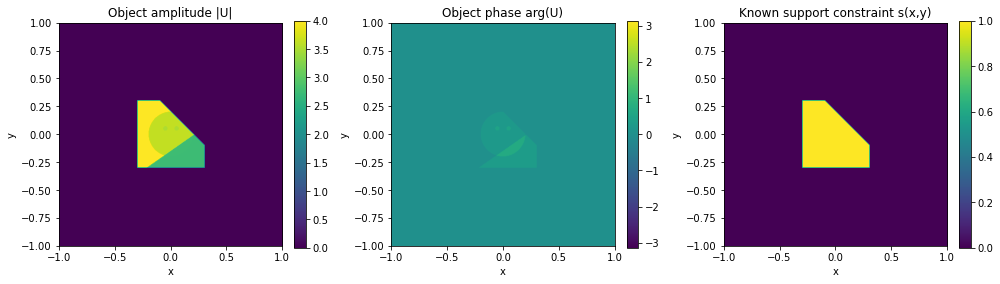

In [3]:
# To reproduce a higher-resolution version, change N to 256 or 512.
N = 512

x = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, x, indexing="xy")

# Support constraint.
support_symmetric = (np.abs(X) < 0.3) & (np.abs(Y) < 0.3)

# To break centrosymmetry and help removing the twin-image ambiguity.
support = support_symmetric & ((X + Y) < 0.2)
s = support.astype(float)

# Define transmitted complex object field U.
U = np.exp(1j * 2 * ((0.7 * X - Y) > 0.15))
U = U + np.exp(1j * ((X**2 + Y**2) < 0.04))
U = U + np.exp(1j * (np.sqrt((X - 0.05)**2 + (Y - 0.05)**2) < 0.02))
U = U + np.exp(1j * (np.sqrt((X + 0.05)**2 + (Y - 0.05)**2) < 0.02))

# Apply support.
U = s * U

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(np.abs(U), extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[0].set_title("Object amplitude |U|")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.angle(U), extent=[x[0], x[-1], x[0], x[-1]], origin="lower", vmin=-np.pi, vmax=np.pi)
axes[1].set_title("Object phase arg(U)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(s, extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[2].set_title("Known support constraint s(x,y)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()


### Define the measured far-field intensity

For coherent far-field diffraction:

$$
I(k_x,k_y)=|\mathcal{F}\{U(x,y)\}|^2.
$$

The detector measures $I$, or equivalently the amplitude

$$
\sqrt{I}=|\hat{U}|.
$$

But it does not measure

$$
\arg(\hat{U}).
$$

So in the algorithm, whenever we go to Fourier space, we enforce the measured amplitude but keep the current guessed phase.

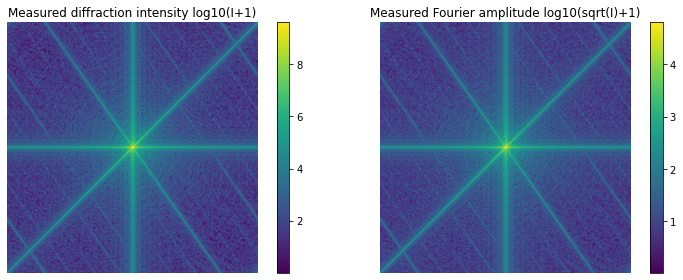

In [4]:
# Synthetic measured diffraction intensity.
U_hat_true = F2d(U)
I_measured = np.abs(U_hat_true)**2
measured_amplitude = np.sqrt(I_measured)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Log display because diffraction patterns often have huge dynamic range.
im0 = axes[0].imshow(np.log10(I_measured + 1), origin="lower")
axes[0].set_title("Measured diffraction intensity log10(I+1)")
axes[0].set_axis_off()
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.log10(measured_amplitude + 1), origin="lower")
axes[1].set_title("Measured Fourier amplitude log10(sqrt(I)+1)")
axes[1].set_axis_off()
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

Clearly, the diffraction pattern looks nothing like the object because it is not an image in the ordinary sense. It is the squared magnitude of the Fourier transform.

Also note:
- sharp object edges produce broad Fourier content;
- many different objects can have similar or identical Fourier magnitudes;
- without phase, simply inverse-transforming $\sqrt{I}$ does not give the object.

Let's demonstrate that last point explicitly.

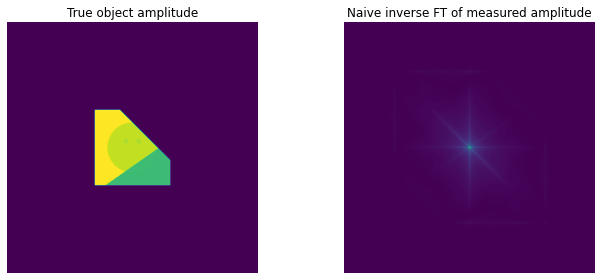

In [5]:
# Naive reconstruction: assume zero Fourier phase.
# This is NOT a valid phase retrieval method; it is a diagnostic.
naive_reconstruction = iF2d(measured_amplitude)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(np.abs(U), origin="lower")
axes[0].set_title("True object amplitude")
axes[0].set_axis_off()

axes[1].imshow(np.abs(naive_reconstruction), origin="lower")
axes[1].set_title("Naive inverse FT of measured amplitude")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

The naive reconstruction fails because we threw away the Fourier phase and replaced it with zero.
This is why the iterative algorithms are needed.


### Projection operators: conceptual version

It helps to define two projections.

#### Fourier modulus projection

Given a current estimate $U_n$, compute:

$$
\hat{U}_n=\mathcal{F}\{U_n\}.
$$

Then replace the magnitude with the measured magnitude while preserving the current phase:

In code we write:

```python
measured_amplitude * np.exp(1j * np.angle(U_hat_est))
```

Then inverse transform:

$$
U_{n,\text{upd}}
=
\mathcal{F}^{-1}\{\hat{U}_{n,\text{new}}\}.
$$

#### Support projection

For ER:

$$
U_{n+1}(x,y)
=
s(x,y)U_{n,\text{upd}}(x,y).
$$

So outside the support, we force the estimate to zero.


In [6]:

def modulus_projection(U_est, measured_amplitude):
    """
    Enforce the Fourier modulus constraint.

    Input:
        U_est : current object estimate in real space.
        measured_amplitude : measured |F{U_true}|.

    Output:
        U_upd : object estimate after replacing Fourier magnitude
                and inverse-transforming back to real space.
    """
    U_hat_est = F2d(U_est)

    # Keep the estimated Fourier phase, replace the Fourier magnitude.
    U_hat_projected = measured_amplitude * np.exp(1j * np.angle(U_hat_est))

    # Return to object space.
    return iF2d(U_hat_projected)


def support_projection(U_est, s):
    """
    Enforce support constraint by setting everything outside support to zero.
    """
    return s * U_est


def er_update(U_est, measured_amplitude, s):
    """
    One Error Reduction iteration.
    """
    U_upd = modulus_projection(U_est, measured_amplitude)
    return support_projection(U_upd, s)


def hio_update(U_est, measured_amplitude, s, beta=0.9):
    """
    One Hybrid Input-Output iteration.

    Inside support:
        accept the modulus-projected update.

    Outside support:
        do not simply set to zero. Instead use feedback:
            U_next = U_old - beta * U_upd

    This feedback helps avoid stagnation.
    """
    U_upd = modulus_projection(U_est, measured_amplitude)
    return s * U_upd + (1 - s) * (U_est - beta * U_upd)



### Useful error metrics

There are several ambiguities in phase retrieval.

Even a perfect reconstruction may differ from the true object by a global phase:

$$
U_\text{recon}(x,y)=e^{i\phi_0}U(x,y).
$$

This global phase is physically irrelevant because intensity measurements cannot determine it.

Therefore, before comparing $U_\text{est}$ to $U$, We will track:

1. **Fourier amplitude error**

   $$
   \frac{\||\mathcal{F}\{U_\text{est}\}|-\sqrt{I}\|_2}{\|\sqrt{I}\|_2}
   $$

2. **Object error inside support**, after best global complex scaling.


In [7]:

support_bool = support.astype(bool)

def align_global_complex_scale(U_est, U_true, mask):
    """
    Find alpha such that alpha * U_est best matches U_true inside mask.

    This removes the physically irrelevant global complex scale/phase ambiguity.
    """
    numerator = np.vdot(U_est[mask], U_true[mask])
    denominator = np.vdot(U_est[mask], U_est[mask]) + 1e-12
    alpha = numerator / denominator
    return alpha * U_est, alpha


def object_relative_error(U_est, U_true, mask):
    """
    Relative object-space error after global complex alignment.
    """
    aligned, _ = align_global_complex_scale(U_est, U_true, mask)
    return np.linalg.norm((aligned - U_true)[mask]) / np.linalg.norm(U_true[mask])


def fourier_amplitude_error(U_est, measured_amplitude):
    """
    Relative Fourier-modulus error.
    """
    return (
        np.linalg.norm(np.abs(F2d(U_est)) - measured_amplitude)
        / np.linalg.norm(measured_amplitude)
    )


In [8]:

def run_phase_retrieval(method, measured_amplitude, s, U_true, num_iterations=120, beta=0.9):
    """
    Run ER or HIO phase retrieval.

    method:
        "ER" or "HIO"

    Returns:
        U_est_history_end : final estimate
        fourier_errors    : Fourier amplitude errors over iteration
        object_errors     : object-space errors over iteration
    """
    U_est = np.ones_like(U_true, dtype=complex)

    fourier_errors = []
    object_errors = []
    iterations = []

    for k in range(num_iterations):
        if method == "ER":
            U_est = er_update(U_est, measured_amplitude, s)
        elif method == "HIO":
            U_est = hio_update(U_est, measured_amplitude, s, beta=beta)
        else:
            raise ValueError("method must be 'ER' or 'HIO'")

        # For object error, compare the physical support-projected object.
        U_for_object_comparison = s * U_est

        if k % 2 == 0 or k == num_iterations - 1:
            iterations.append(k + 1)
            fourier_errors.append(fourier_amplitude_error(U_est, measured_amplitude))
            object_errors.append(object_relative_error(U_for_object_comparison, U_true, support_bool))

    return U_est, np.array(iterations), np.array(fourier_errors), np.array(object_errors)


num_iterations = 120
beta = 0.9

U_er, it_er, fourier_er, object_er = run_phase_retrieval(
    "ER", measured_amplitude, s, U, num_iterations=num_iterations, beta=beta
)

U_hio, it_hio, fourier_hio, object_hio = run_phase_retrieval(
    "HIO", measured_amplitude, s, U, num_iterations=num_iterations, beta=beta
)

print("Final ER object error:", object_er[-1])
print("Final HIO object error:", object_hio[-1])


Final ER object error: 0.24685733449933747
Final HIO object error: 0.0014885494895408359


### Visual comparison

For ER, the estimate is already forced to zero outside the support.

For HIO, the raw estimate can contain nonzero values outside the support because this is part of the feedback mechanism. Therefore, for displaying the reconstructed object we plot:

$$
s(x,y)U_\text{HIO}(x,y).
$$

This is the part of the HIO estimate inside the known object support.


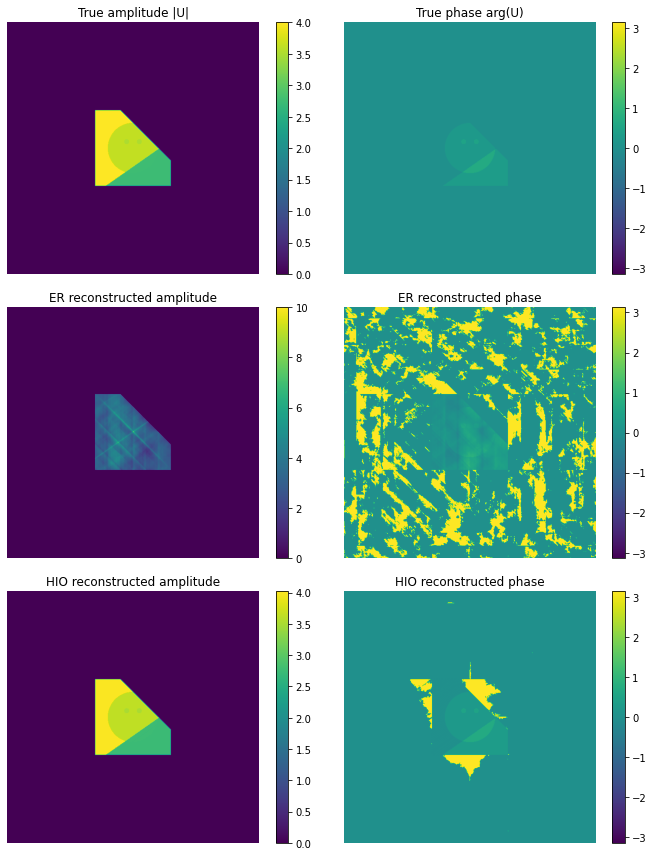

In [9]:

# Support-projected versions for physical object visualization.
U_er_phys = s * U_er
U_hio_phys = s * U_hio

# Align global phase/scale for fair visualization.
U_er_aligned, alpha_er = align_global_complex_scale(U_er_phys, U, support_bool)
U_hio_aligned, alpha_hio = align_global_complex_scale(U_hio_phys, U, support_bool)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

plots = [
    (np.abs(U), "True amplitude |U|", None),
    (np.angle(U), "True phase arg(U)", (-np.pi, np.pi)),
    (np.abs(U_er_aligned), "ER reconstructed amplitude", None),
    (np.angle(U_er_aligned), "ER reconstructed phase", (-np.pi, np.pi)),
    (np.abs(U_hio_aligned), "HIO reconstructed amplitude", None),
    (np.angle(U_hio_aligned), "HIO reconstructed phase", (-np.pi, np.pi)),
]

for ax, (img, title, limits) in zip(axes.flat, plots):
    if limits is None:
        im = ax.imshow(img, origin="lower")
    else:
        im = ax.imshow(img, origin="lower", vmin=limits[0], vmax=limits[1])
    ax.set_title(title)
    ax.set_axis_off()
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


#### Result reasoning

ER tends to recover a recognizable object but seems it stagnated.

HIO recovers sharper/more accurate phase features because its feedback step helps it escape bad fixed points.

Phase plots can look noisy in low-amplitude regions because phase is meaningless where amplitude is near zero.

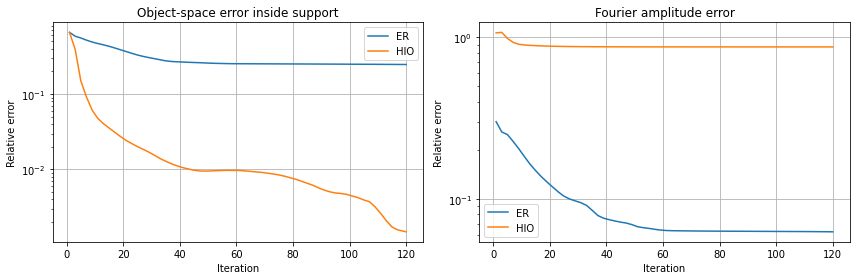

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(it_er, object_er, label="ER")
axes[0].semilogy(it_hio, object_hio, label="HIO")
axes[0].set_title("Object-space error inside support")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Relative error")
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy(it_er, fourier_er, label="ER")
axes[1].semilogy(it_hio, fourier_hio, label="HIO")
axes[1].set_title("Fourier amplitude error")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Relative error")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### HIO followed by ER refinement

A common practical recipe is:

1. Run HIO to escape stagnation and get close to a solution.
2. Run ER afterwards to clean up and enforce constraints more strictly.

This makes sense intuitively:

- HIO is aggressive and exploratory.
- ER is conservative and refining.

In [11]:

def run_hio_then_er(measured_amplitude, s, U_true, n_hio=100, n_er=40, beta=0.9):
    U_est = np.ones_like(U_true, dtype=complex)

    object_errors = []
    labels = []

    for k in range(n_hio):
        U_est = hio_update(U_est, measured_amplitude, s, beta=beta)
        if k % 2 == 0:
            object_errors.append(object_relative_error(s * U_est, U_true, support_bool))
            labels.append(k + 1)

    for k in range(n_er):
        U_est = er_update(U_est, measured_amplitude, s)
        if k % 2 == 0 or k == n_er - 1:
            object_errors.append(object_relative_error(s * U_est, U_true, support_bool))
            labels.append(n_hio + k + 1)

    return U_est, np.array(labels), np.array(object_errors)


U_hio_er, it_hio_er, obj_hio_er = run_hio_then_er(
    measured_amplitude, s, U, n_hio=100, n_er=40, beta=beta
)

U_hio_er_phys = s * U_hio_er
U_hio_er_aligned, _ = align_global_complex_scale(U_hio_er_phys, U, support_bool)

print("Final HIO+ER object error:", obj_hio_er[-1])


Final HIO+ER object error: 0.005167004218252043


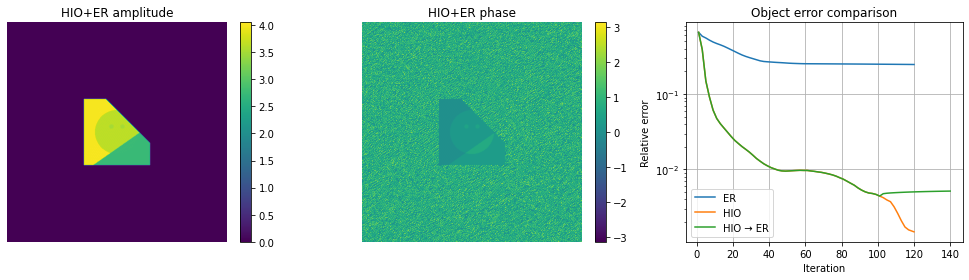

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(np.abs(U_hio_er_aligned), origin="lower")
axes[0].set_title("HIO+ER amplitude")
axes[0].set_axis_off()
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.angle(U_hio_er_aligned), origin="lower", vmin=-np.pi, vmax=np.pi)
axes[1].set_title("HIO+ER phase")
axes[1].set_axis_off()
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].semilogy(it_er, object_er, label="ER")
axes[2].semilogy(it_hio, object_hio, label="HIO")
axes[2].semilogy(it_hio_er, obj_hio_er, label="HIO → ER")
axes[2].set_title("Object error comparison")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Relative error")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()
